In [21]:
# 1) 나눔고딕 폰트 설치
!apt-get update -qq
!apt-get install -qq fonts-nanum

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [23]:
# 기본 라이브러리
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# 2) matplotlib에 폰트 등록 & 설정
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 나눔고딕 경로 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)

# 전체 폰트 설정
mpl.rc('font', family='NanumGothic')
# 음수 부호 깨짐 방지
mpl.rc('axes', unicode_minus=False)

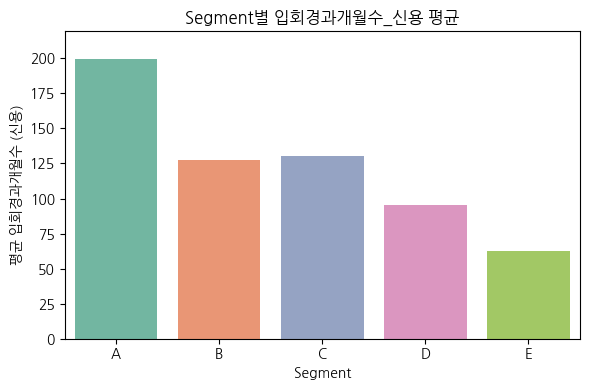

In [26]:


# 1) Parquet 파일 읽기
file_path = '/content/drive/MyDrive/data/train/1.회원정보/201807_train_회원정보.parquet'
df = pd.read_parquet(file_path)

# 2) 세그먼트별 평균 계산
seg_order = ['A', 'B', 'C', 'D', 'E']
mean_df = (
    df.groupby('Segment')['입회경과개월수_신용']
      .mean()
      .reindex(seg_order)
      .reset_index()
      .rename(columns={'입회경과개월수_신용': 'mean_months'})
)

# 3) 바 플롯 그리기
plt.figure(figsize=(6, 4))
sns.barplot(
    data=mean_df,
    x='Segment',
    y='mean_months',
    order=seg_order,
    palette='Set2'
)
plt.title('Segment별 입회경과개월수_신용 평균')
plt.xlabel('Segment')
plt.ylabel('평균 입회경과개월수 (신용)')
plt.ylim(0, mean_df['mean_months'].max() * 1.1)  # y축 하한 0, 상한은 여유 있게
plt.tight_layout()
plt.show()

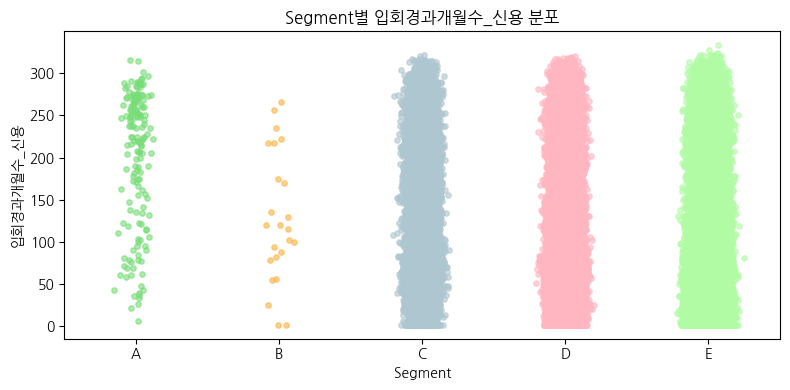

In [27]:
# 1) 회원정보 파일 불러오기
df = pd.read_parquet('/content/drive/MyDrive/data/train/1.회원정보/201807_train_회원정보.parquet')

# 2) 색상 매핑 및 세그먼트 순서
colors = {
    'A': '#77DD77',  # 파스텔 그린
    'B': '#FFB347',  # 파스텔 오렌지
    'C': '#AEC6CF',  # 파스텔 블루
    'D': '#FFB6C1',  # 파스텔 핑크
    'E': '#B2FBA5',  # 연두
}
order = ['A','B','C','D','E']

# 3) 스캐터플롯
plt.figure(figsize=(8,4))
for i, seg in enumerate(order):
    vals = df.loc[df['Segment']==seg, '입회경과개월수_신용'].dropna().values
    xs = np.random.normal(loc=i, scale=0.05, size=len(vals))  # jitter
    plt.scatter(xs, vals, color=colors[seg], alpha=0.6, s=15)

plt.xticks(range(len(order)), order)
plt.xlim(-0.5, len(order)-0.5)
plt.xlabel('Segment')
plt.ylabel('입회경과개월수_신용')
plt.title('Segment별 입회경과개월수_신용 분포')
plt.tight_layout()
plt.show()

/tmp/ipython-input-15-2617462523.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


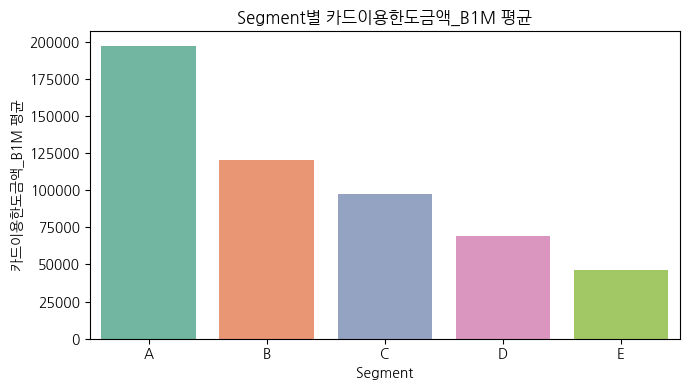

/tmp/ipython-input-15-2617462523.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


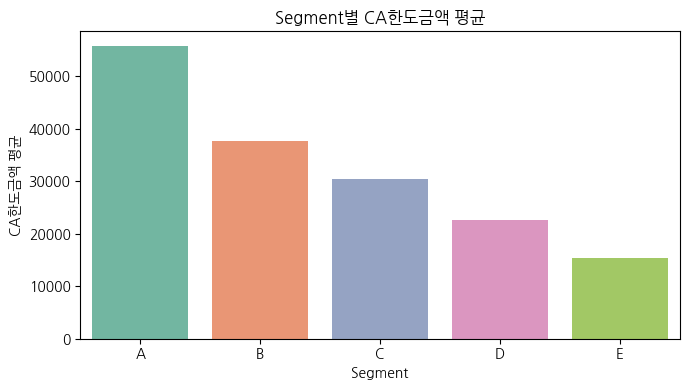

In [ ]:
# 2) 데이터 불러오기
member_path = '/content/drive/MyDrive/data/train/1.회원정보/201807_train_회원정보.parquet'
credit_path = '/content/drive/MyDrive/data/train/2.신용정보/201807_train_신용정보.parquet'
df_member = pd.read_parquet(member_path)[['ID','기준년월','Segment']]
df_credit = pd.read_parquet(credit_path)[['ID','기준년월','카드이용한도금액_B1M','CA한도금액']]

# 3) 병합
df = pd.merge(df_credit, df_member, on=['ID','기준년월'], how='left')

# 4) 시각화 설정
segment_order = ['A','B','C','D','E']
cols = ['카드이용한도금액_B1M','CA한도금액']

# 5) 각 칼럼별 Segment A→E 막대그래프
for col in cols:
    plt.figure(figsize=(7,4))
    sns.barplot(
        data=df,
        x='Segment',
        y=col,
        order=segment_order,
        errorbar=None,     # 표준편차 막대 제거
        palette='Set2'
    )
    plt.title(f'Segment별 {col} 평균')
    plt.xlabel('Segment')
    plt.ylabel(f'{col} 평균')
    plt.ylim(0, None)
    plt.tight_layout()
    plt.show()

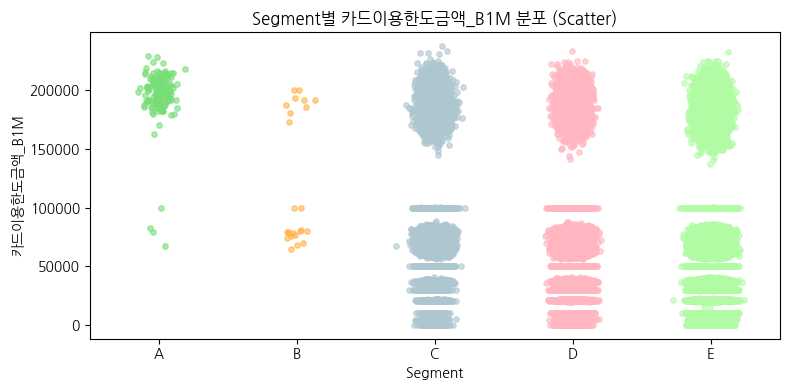

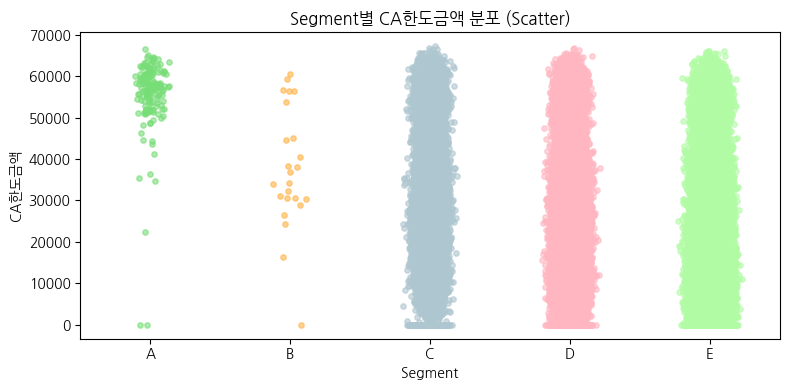

In [28]:
# 1) 데이터 불러오기
member_path = '/content/drive/MyDrive/data/train/1.회원정보/201807_train_회원정보.parquet'
credit_path = '/content/drive/MyDrive/data/train/2.신용정보/201807_train_신용정보.parquet'
df_member = pd.read_parquet(member_path)[['ID','기준년월','Segment']]
df_credit = pd.read_parquet(credit_path)[['ID','기준년월','카드이용한도금액_B1M','CA한도금액']]

# 2) 병합
df = pd.merge(df_credit, df_member, on=['ID','기준년월'], how='left')

# 3) 시각화 설정
segment_order = ['A','B','C','D','E']
cols = ['카드이용한도금액_B1M','CA한도금액']

# 파스텔톤 색상 매핑
color_map = {
    'A': '#77DD77',  # 파스텔 그린
    'B': '#FFB347',  # 파스텔 오렌지
    'C': '#AEC6CF',  # 파스텔 블루
    'D': '#FFB6C1',  # 파스텔 핑크
    'E': '#B2FBA5',  # 연두
}

# 4) 스캐터플롯 생성
for col in cols:
    plt.figure(figsize=(8, 4))
    for i, seg in enumerate(segment_order):
        vals = df.loc[df['Segment'] == seg, col].dropna().values
        # x 위치에 jitter 추가
        xs = np.random.normal(loc=i, scale=0.05, size=len(vals))
        plt.scatter(xs, vals,
                    color=color_map[seg],
                    alpha=0.6,
                    s=15,
                    label=seg if i == 0 else "")

    plt.xticks(range(len(segment_order)), segment_order)
    plt.xlim(-0.5, len(segment_order) - 0.5)
    plt.title(f'Segment별 {col} 분포 (Scatter)')
    plt.xlabel('Segment')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

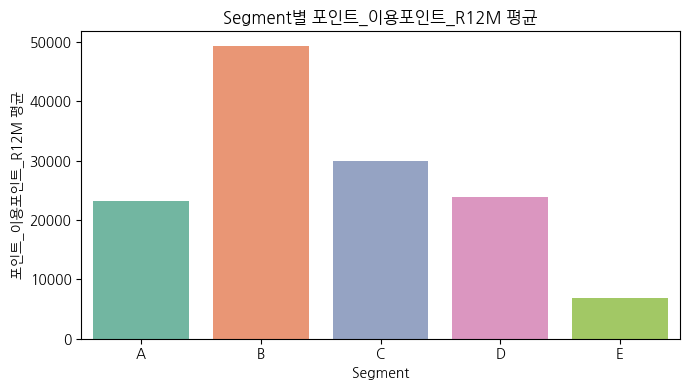

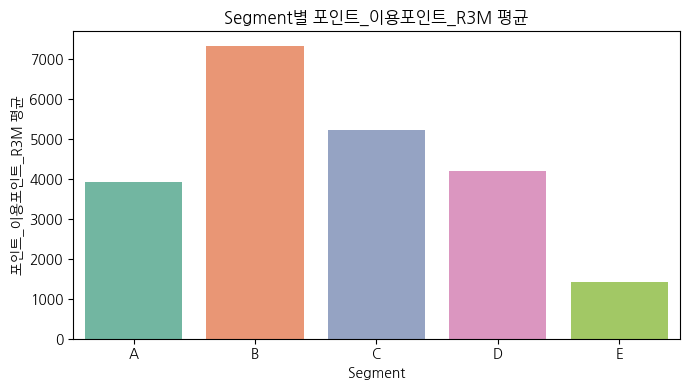

In [29]:
# 2) 데이터 불러오기
member_path = '/content/drive/MyDrive/data/train/1.회원정보/201807_train_회원정보.parquet'
credit_path = '/content/drive/MyDrive/data/train/4.청구입금정보/201807_train_청구정보.parquet'
df_member = pd.read_parquet(member_path)[['ID','기준년월','Segment']]
df_credit = pd.read_parquet(credit_path)[['ID','기준년월','포인트_이용포인트_R12M', '포인트_이용포인트_R3M']]

# 3) 병합
df = pd.merge(df_credit, df_member, on=['ID','기준년월'], how='left')

# 4) 시각화 설정
segment_order = ['A','B','C','D','E']
cols = ['포인트_이용포인트_R12M', '포인트_이용포인트_R3M']

# 5) 각 칼럼별 Segment A→E 막대그래프
for col in cols:
    plt.figure(figsize=(7,4))
    sns.barplot(
        data=df,
        x='Segment',
        y=col,
        order=segment_order,
        errorbar=None,     # 표준편차 막대 제거
        palette='Set2'
    )
    plt.title(f'Segment별 {col} 평균')
    plt.xlabel('Segment')
    plt.ylabel(f'{col} 평균')
    plt.ylim(0, None)
    plt.tight_layout()
    plt.show()

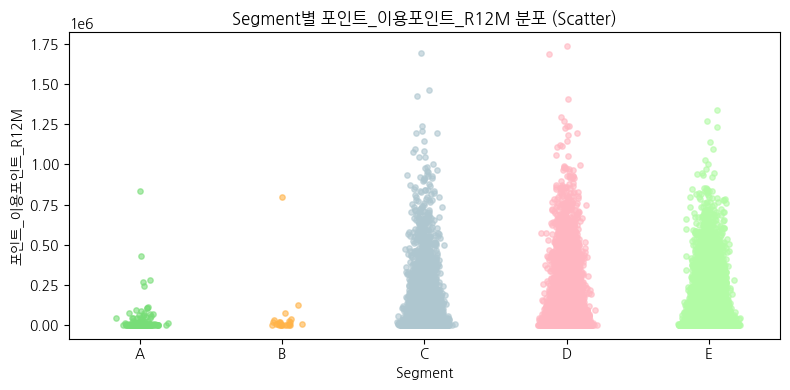

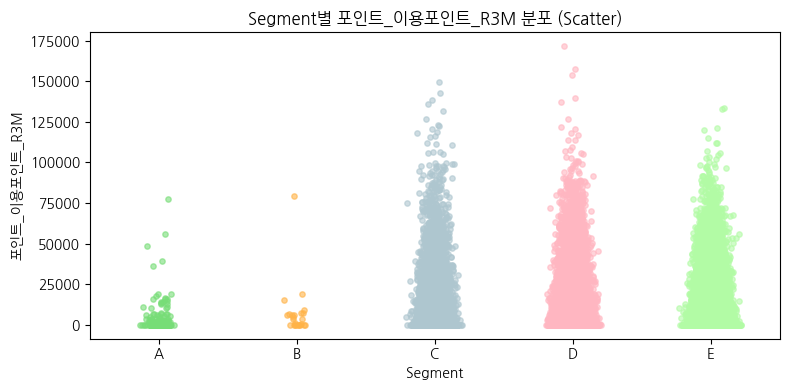

In [30]:
# 4) 시각화 설정 (앞서 정의된 df, segment_order, cols 사용)
# 파스텔톤 색상 매핑
color_map = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}

# 5) 스캐터플롯 생성
for col in cols:
    plt.figure(figsize=(8, 4))
    for i, seg in enumerate(segment_order):
        vals = df.loc[df['Segment'] == seg, col].dropna().values
        # x 위치에 jitter 추가
        xs = np.random.normal(loc=i, scale=0.05, size=len(vals))
        plt.scatter(xs, vals,
                    color=color_map[seg],
                    alpha=0.6,
                    s=15)

    plt.xticks(range(len(segment_order)), segment_order)
    plt.xlim(-0.5, len(segment_order) - 0.5)
    plt.title(f'Segment별 {col} 분포 (Scatter)')
    plt.xlabel('Segment')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

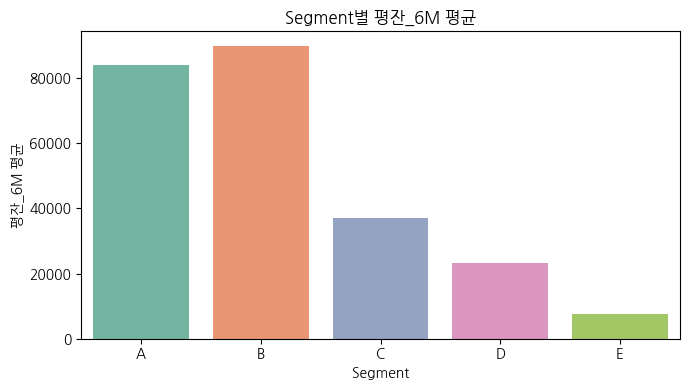

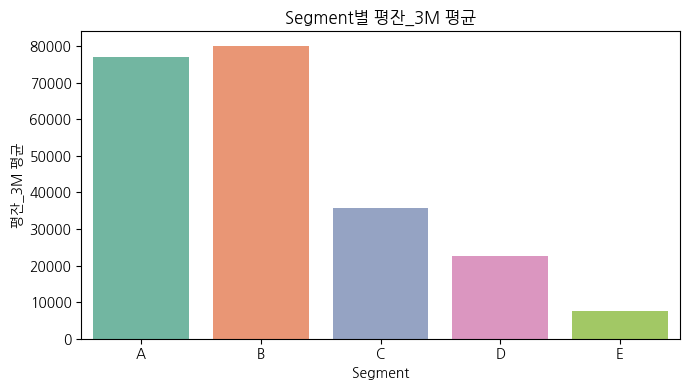

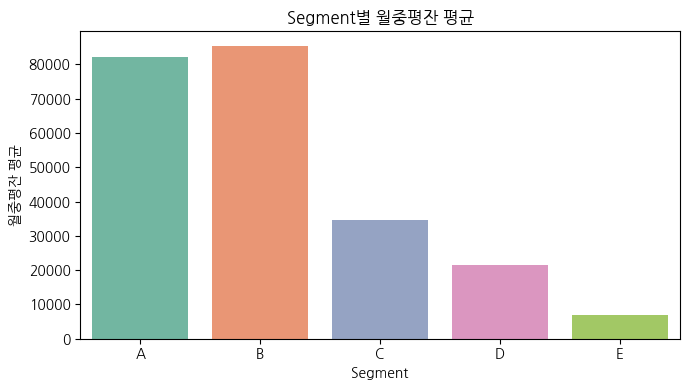

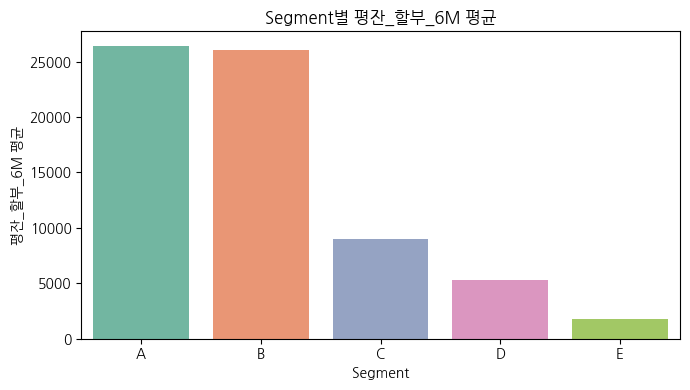

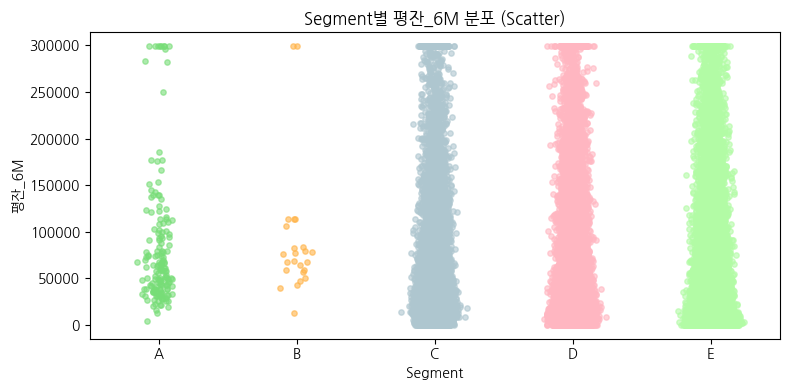

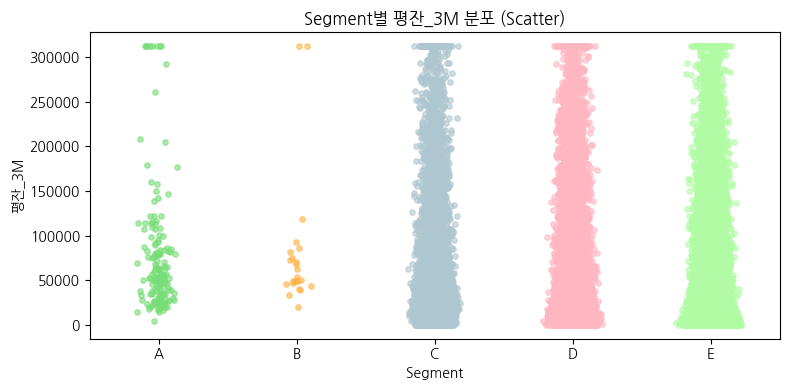

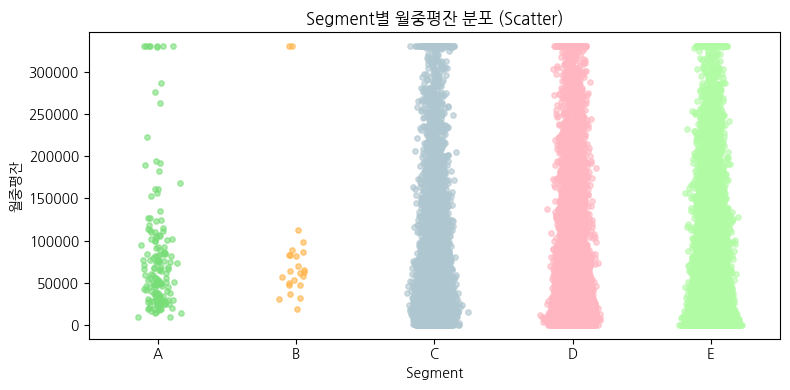

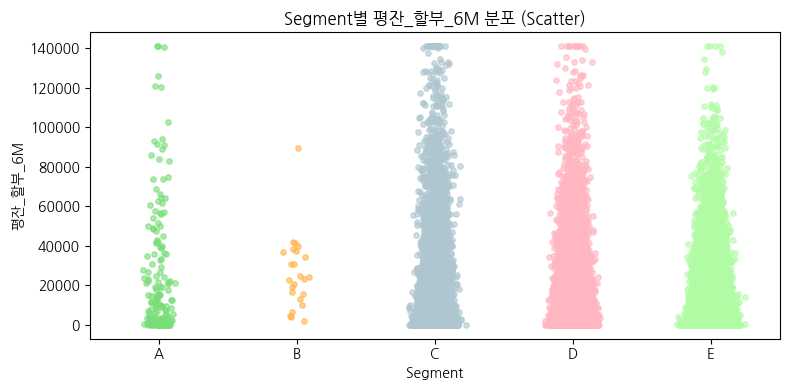

In [31]:
# 2) 데이터 불러오기
member_path = '/content/drive/MyDrive/data/train/1.회원정보/201807_train_회원정보.parquet'
credit_path = '/content/drive/MyDrive/data/train/5.잔액정보/201807_train_잔액정보.parquet'
df_member = pd.read_parquet(member_path)[['ID','기준년월','Segment']]
df_credit = pd.read_parquet(credit_path)[['ID','기준년월','평잔_6M','평잔_3M','월중평잔','평잔_할부_6M']]

# 3) 병합
df = pd.merge(df_credit, df_member, on=['ID','기준년월'], how='left')

# 4) 시각화 설정
segment_order = ['A','B','C','D','E']
cols = ['평잔_6M','평잔_3M','월중평잔','평잔_할부_6M']

# 5) 각 칼럼별 Segment A→E 막대그래프
for col in cols:
    plt.figure(figsize=(7,4))
    sns.barplot(
        data=df,
        x='Segment',
        y=col,
        order=segment_order,
        errorbar=None,     # 표준편차 막대 제거
        palette='Set2'
    )
    plt.title(f'Segment별 {col} 평균')
    plt.xlabel('Segment')
    plt.ylabel(f'{col} 평균')
    plt.ylim(0, None)
    plt.tight_layout()
    plt.show()
# 스캐터 플랏
  # 파스텔톤 색상 매핑
color_map = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}

# cols, segment_order, df 는 이전에 정의된 상태라고 가정
for col in cols:
    plt.figure(figsize=(8, 4))
    for i, seg in enumerate(segment_order):
        vals = df.loc[df['Segment'] == seg, col].dropna().values
        xs = np.random.normal(loc=i, scale=0.05, size=len(vals))
        plt.scatter(xs, vals, color=color_map[seg], alpha=0.6, s=15)
    plt.xticks(range(len(segment_order)), segment_order)
    plt.xlim(-0.5, len(segment_order) - 0.5)
    plt.title(f'Segment별 {col} 분포 (Scatter)')
    plt.xlabel('Segment')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

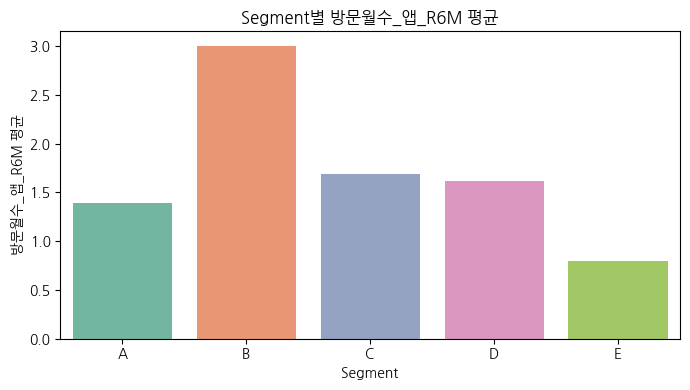

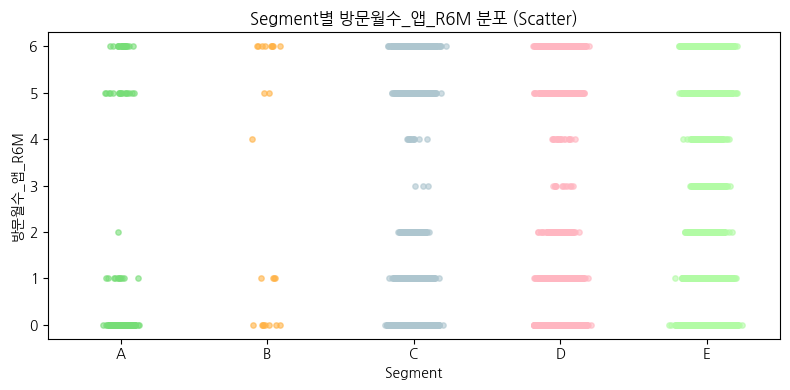

In [32]:
# 2) 데이터 불러오기
member_path = '/content/drive/MyDrive/data/train/1.회원정보/201807_train_회원정보.parquet'
credit_path = '/content/drive/MyDrive/data/train/6.채널정보/201807_train_채널정보.parquet'
df_member = pd.read_parquet(member_path)[['ID','기준년월','Segment']]
df_credit = pd.read_parquet(credit_path)[['ID','기준년월','방문월수_앱_R6M']]

# 3) 병합
df = pd.merge(df_credit, df_member, on=['ID','기준년월'], how='left')

# 4) 시각화 설정
segment_order = ['A','B','C','D','E']
cols = ['방문월수_앱_R6M']

# 5) 각 칼럼별 Segment A→E 막대그래프
for col in cols:
    plt.figure(figsize=(7,4))
    sns.barplot(
        data=df,
        x='Segment',
        y=col,
        order=segment_order,
        errorbar=None,     # 표준편차 막대 제거
        palette='Set2'
    )
    plt.title(f'Segment별 {col} 평균')
    plt.xlabel('Segment')
    plt.ylabel(f'{col} 평균')
    plt.ylim(0, None)
    plt.tight_layout()
    plt.show()

# 스캐터 플랏
  # 파스텔톤 색상 매핑
color_map = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}

# cols, segment_order, df 는 이전에 정의된 상태라고 가정
for col in cols:
    plt.figure(figsize=(8, 4))
    for i, seg in enumerate(segment_order):
        vals = df.loc[df['Segment'] == seg, col].dropna().values
        xs = np.random.normal(loc=i, scale=0.05, size=len(vals))
        plt.scatter(xs, vals, color=color_map[seg], alpha=0.6, s=15)
    plt.xticks(range(len(segment_order)), segment_order)
    plt.xlim(-0.5, len(segment_order) - 0.5)
    plt.title(f'Segment별 {col} 분포 (Scatter)')
    plt.xlabel('Segment')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

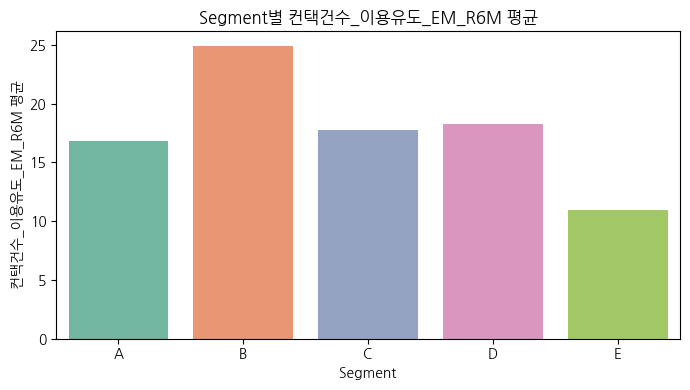

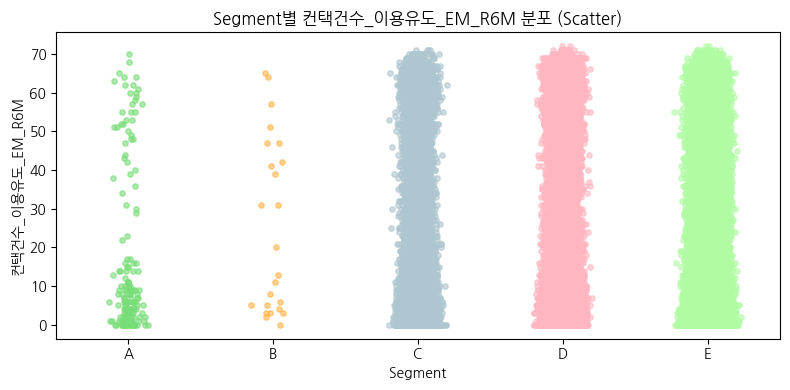

In [33]:
# 2) 데이터 불러오기
member_path = '/content/drive/MyDrive/data/train/1.회원정보/201807_train_회원정보.parquet'
credit_path = '/content/drive/MyDrive/data/train/7.마케팅정보/201807_train_마케팅정보.parquet'
df_member = pd.read_parquet(member_path)[['ID','기준년월','Segment']]
df_credit = pd.read_parquet(credit_path)[['ID','기준년월','컨택건수_이용유도_EM_R6M']]

# 3) 병합
df = pd.merge(df_credit, df_member, on=['ID','기준년월'], how='left')

# 4) 시각화 설정
segment_order = ['A','B','C','D','E']
cols = ['컨택건수_이용유도_EM_R6M']

# 5) 각 칼럼별 Segment A→E 막대그래프
for col in cols:
    plt.figure(figsize=(7,4))
    sns.barplot(
        data=df,
        x='Segment',
        y=col,
        order=segment_order,
        errorbar=None,     # 표준편차 막대 제거
        palette='Set2'
    )
    plt.title(f'Segment별 {col} 평균')
    plt.xlabel('Segment')
    plt.ylabel(f'{col} 평균')
    plt.ylim(0, None)
    plt.tight_layout()
    plt.show()

# 스캐터 플랏
  # 파스텔톤 색상 매핑
color_map = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}

# cols, segment_order, df 는 이전에 정의된 상태라고 가정
for col in cols:
    plt.figure(figsize=(8, 4))
    for i, seg in enumerate(segment_order):
        vals = df.loc[df['Segment'] == seg, col].dropna().values
        xs = np.random.normal(loc=i, scale=0.05, size=len(vals))
        plt.scatter(xs, vals, color=color_map[seg], alpha=0.6, s=15)
    plt.xticks(range(len(segment_order)), segment_order)
    plt.xlim(-0.5, len(segment_order) - 0.5)
    plt.title(f'Segment별 {col} 분포 (Scatter)')
    plt.xlabel('Segment')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()